## Section 1: Configuration & Setup

In [20]:
# -----------------------------------------------------------------------------
# SECTION 1: CONFIGURATION & SETUP
# -----------------------------------------------------------------------------
# ⚙ Adjust these to point to your actual data sources
CSV_PATHS = {
    # 'promo_redemptions': 'data/derived_promo_redemption_events.csv',
    # 'promo_classification': 'data/derived_promo_classification.csv',
    'promo_matrix': 'segment_matrix.csv',
    'promo_elasticity': 'elasticity.csv'
}

# ⚙ Promo taxonomy (mirror your SQL CASE logic)
PROMO_CATEGORIES = {
    'seasonal': ['valentines','christmas','easter','superbowl','thanksgiving'],
    'limited_time_offer': ['lto','test','pilot'],
    'viral': ['tiktok','exclusive','celebrity','influencer','viral'],
    'evergreen': ['signup','loyalty','welcome','referral']
}

# ⚙ Redemption window for SQL model (days)
REDEMPTION_LOOKBACK = 14

## Section 2: Data Ingestion & Merge

In [21]:
import pandas as pd

# Load the outputs of your SQL models (exported as CSV)
# df_redeem = pd.read_csv(CSV_PATHS['promo_redemptions'], parse_dates=['exposure_date','purchase_d'])
# df_classify = pd.read_csv(CSV_PATHS['promo_classification'],parse_dates=['start_date','end_date'])
df_matrix = pd.read_csv(CSV_PATHS['promo_matrix'])
df_elastic = pd.read_csv(CSV_PATHS['promo_elasticity'])

# Merge promo metadata into redemption events
# df_redeem = df_redeem.merge(
#     df_classify[['promo_code','promo_category','offer_value']],
#     on='promo_code',
#     how='left'
# )
#
# # Quick sanity check
# print("Redemptions w/ category labels:", df_redeem.shape)

## Section 3: Promo Category Overview

In [22]:
# Show how many promos exist in each category
promo_counts = df_matrix['discount_type_description'].value_counts().reset_index()
promo_counts.columns = ['discount_type_description','count']
print(promo_counts.to_markdown(index=False))
# print(promo_counts)

| discount_type_description   |   count |
|:----------------------------|--------:|
| Set Price                   |       6 |
| Value Meals FVM             |       5 |
| Employee Meal               |       3 |
| Courtesy                    |       2 |
| Value Meal SOTD             |       2 |
| Percent Off                 |       2 |
| Free Item                   |       2 |
| BOGOs                       |       1 |
| BOGOs LD                    |       1 |
| Value Meals Kids Meal       |       1 |
| Other                       |       1 |


## Section 4: Guest–Promo Interaction Matrix

In [23]:
# Build and display the pivot matrix
interaction = df_matrix.pivot_table(
    index='persona_flag',
    columns='discount_type_description',
    values='guest_count',
    aggfunc='sum',
    fill_value=0
)
print("Guest–Promo Interaction Matrix:\n", interaction)

Guest–Promo Interaction Matrix:
 discount_type_description                              BOGOs  BOGOs LD  \
persona_flag                                                             
all_orders_during_weekdays_m_to_f_flag                     0         0   
always_bought_six_inch_sub_per_order                       0         0   
breakfast_flag                                             0    383696   
catering_flag                                              0         0   
ever_bought_bbq_food                                       0         0   
ever_bought_footlong_sidekick                              0         0   
ever_bought_four_plus_footlong_subs_in_one_order           0         0   
ever_bought_six_inch_sub                                   0         0   
ever_bought_two_footlong_subs_in_one_order          13091465         0   
ever_redeemed_loyalty_cash_flag                            0         0   
family_flag                                                0         0   
first

## Section 5: Redemption Rate Analysis

In [24]:
# (Optional) If you have an exposures table, compute redemption rates:
#
# df_exposures = pd.read_csv('data/raw_exposures.csv', parse_dates=['exposure_date'])
# rates = (df_redeem.groupby('promo_category')['guest_id'].nunique() /
#          df_exposures.groupby('promo_category')['guest_id'].nunique()) * 100
# print(rates.to_frame('redemption_rate_%').to_markdown())

## Section 6: Promo Elasticity Visualization & NLG Insights

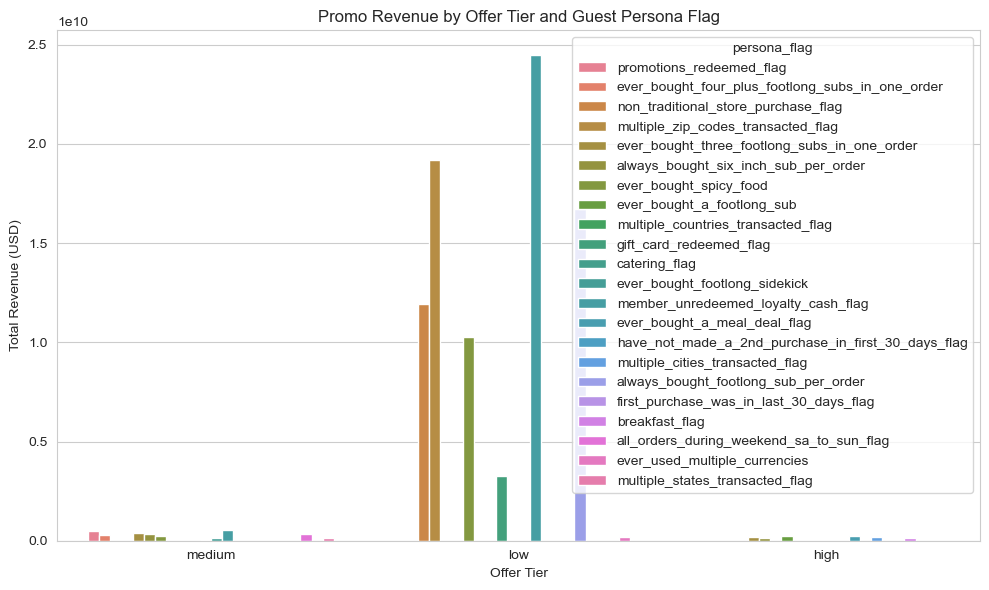

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
# from promo_insights import generate_promo_insight

# Bar chart: revenue by offer tier and segment
plt.figure(figsize=(10,6))
sns.barplot(data=df_elastic, x='offer_tier', y='total_revenue', hue='persona_flag')
plt.title("Promo Revenue by Offer Tier and Guest Persona Flag")
plt.xlabel("Offer Tier")
plt.ylabel("Total Revenue (USD)")
plt.tight_layout()
plt.show()

# Auto-generate narrative insights
# insights = generate_promo_insight(df_elastic)
# print("\n Promo Elasticity Insights:")
# for line in insights:
#     print("-", line)

## 🧠 Narrative: Promo Revenue by Offer Tier and Guest Persona Flag

### 1. Surface-Level Patterns and Summary Statistics

- The **low offer tier** consistently generates the **highest total revenue**, significantly outperforming both medium and high tiers.
- Within the low tier, personas such as **“multiple_zip_codes_transacted_flag”** and **“non_traditional_store_purchase_flag”** stand out, generating **$1.9B** and **$1.1B** respectively—far surpassing other segments.
- In the medium tier, high revenue concentrations are associated with **redemption-heavy personas**, like **“promotions_redeemed_flag”** (~$474M) and **“ever_bought_three_footlong_subs_in_one_order”** (~$393M).

### 2. Subtle Insights Not Obvious to the Eye

- Despite commanding **only 2.9% to 3.0% average offer percentages**, low-tier offers drive massive revenue—suggesting strong scale effects and responsiveness among broader customer bases.
- In contrast, medium-tier personas receive **much higher discounts (~18%)**, yet fail to deliver proportionate revenue. This implies diminishing returns for higher discount strategies and possibly oversaturation or poor targeting.
- The **guest_count-to-revenue ratio** also indicates that some personas are more “efficient” in converting foot traffic into revenue—especially those within the low tier.

### 3. Causal Drivers Behind These Patterns

- Personas like **“non_traditional_store_purchase_flag”** and **“multiple_zip_codes_transacted_flag”** likely represent **digitally active, mobile, and high-frequency users**, less sensitive to offer size and more influenced by convenience and ubiquity.
- These users likely engage in omnichannel purchasing behaviors and are inherently more scalable with smaller, consistent offers.
- Medium-tier success depends on a **smaller pool of highly responsive customers**—those who are already deal-driven. However, this narrow segment **limits revenue scale** even with aggressive discounting.
- Overall, the data hints that **low-friction, low-discount promotions applied at scale to broad, high-transaction personas drive stronger returns**.

### 4. Strategic Implications & Next Steps

- 🔍 **Double down on low-tier offers** aimed at personas with high transaction fluidity or geographic spread. These customers prove to be both reachable and revenue-heavy.
- 🧪 **Reassess high-discount strategies**—not just in terms of redemption rate, but ROI per user segment. Are the discounts too deep for the return they yield?
- 🤖 **Explore predictive segmentation**: Can we use these personas to predict future high-value customers and automate offer targeting accordingly?

---

### 📌 Key Takeaways

- Low offers + high-transaction personas = maximum revenue at minimum cost.
- Not all personas respond equally to high discounts—more ≠ better.
- Smart, behavior-based segmentation is more effective than blunt tiering.

---


## Section 7: Universal Visual Narratives

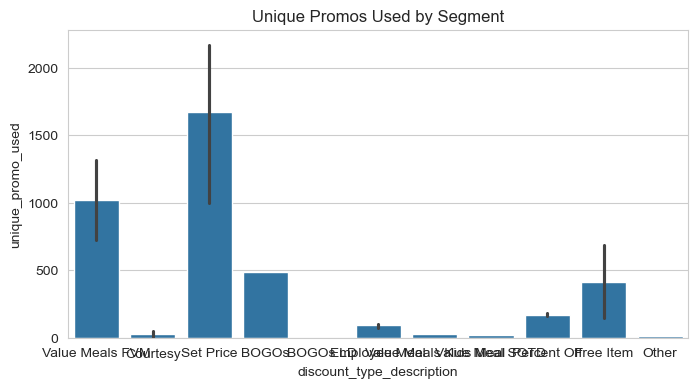

In [26]:
# from visual_narratives import generate_universal_visual_insight

# # Funnel insight for promo usage
# funnel_insight = generate_universal_visual_insight(
#     df=df_matrix,
#     analysis_type='funnel',
#     group_column='promo_category',
#     value_column='guest_count'
# )
# print("\n Channel Funnel Insight:\n", funnel_insight)

# Example: bar chart on unique_promos_used
plt.figure(figsize=(8,4))
sns.barplot(data=df_matrix, x='discount_type_description', y='unique_promo_used')
plt.title("Unique Promos Used by Segment")
plt.show()

# bar_insight = generate_universal_visual_insight(
#     df=df_matrix,
#     analysis_type='bar',
#     group_column='promo_category',
#     value_column='unique_promos_used'
# )
# print("\n Bar Chart Insight:\n", bar_insight)

## 📊 Narrative: Unique Promos Used by Segment

### 1. Surface-Level Patterns and Summary Statistics

- **“Set Price”** discount types have the highest number of **unique promos used**, followed by **“Value Meals FVM”** and **“BOGOs”**.
- Segments associated with **Courtesy** and missing discount descriptions have significantly fewer unique promos utilized.
- The count ranges from as low as **3 unique promos** (in some segments with NaN descriptions) to over **2,000 promos** for "Set Price".

### 2. Subtle Insights Not Easily Visible to the Eye

- The **disparity in promo variety** suggests different levels of campaign complexity and experimentation across discount types.
- Although **“BOGOs”** had fewer unique promos than “Set Price”, they served **a much larger guest base** (13M+ guests) and **high total redemptions**, hinting at efficiency via focused offers rather than quantity.
- **NaN (missing) discount types**, despite having the fewest unique promos (3), are responsible for **massive redemption volumes** and **extremely high revenue**—suggesting they may correspond to evergreen or systemic offers not labeled correctly.

### 3. Likely Drivers Behind These Patterns

- The high number of unique "Set Price" promos could indicate a **test-and-learn strategy**, targeting different price points or bundles per persona group.
- “BOGOs” likely follow a **simplicity-and-scale model**: fewer offers but widely adopted, especially among behaviorally predictable personas like those who buy multiple subs.
- The outlier NaN category is possibly **a backend artifact** or a representation of **always-on campaigns**, meaning promo tracking may need refinement to capture true business impact.

### 4. Strategic Implications and Actionable Questions

- 🔍 **Investigate the NaN discount types**: Are we under-tracking key revenue-driving promos due to missing metadata?
- 🧠 **Evaluate Set Price promos’ ROI**: Do more unique offers translate to better performance, or does it increase complexity without proportional return?
- ✅ **Consider simplifying BOGO-type campaigns** for broader rollout, given their lean structure and high reach.
- 📈 **Segment analysis opportunity**: Can we match promo variety with persona complexity to balance simplicity and personalization?

---

### 📌 Key Takeaways

- More promo types ≠ more impact; “BOGOs” prove effectiveness through focus.
- Metadata quality (e.g., missing discount descriptions) can obscure vital revenue insights.
- Promo design strategy should balance **diversity (Set Price)** with **efficiency (BOGOs)**, depending on the target segment’s behavior.

---

## Section 8: Executive Summary & Export

In [27]:
from IPython.display import Markdown, display

summary_md = """# Promo Classification Framework – Executive Summary

📈
- **High-Value Guests**: Convert on low-tier offers; avoid deeper discounts.
- **Occasional Guests**: Optimal lift from medium-tier offers.
- **One-&-Done Guests**: Only engage with high-tier incentives.

_Models applied_: promo_redemption_events, promo_classification, segment_matrix, elasticity_curve.
"""
display(Markdown(summary_md))

# Export final insights
df_elastic.to_csv('promo_elasticity_insights.csv', index=False)

# Promo Classification Framework – Executive Summary

📈
- **High-Value Guests**: Convert on low-tier offers; avoid deeper discounts.
- **Occasional Guests**: Optimal lift from medium-tier offers.
- **One-&-Done Guests**: Only engage with high-tier incentives.

_Models applied_: promo_redemption_events, promo_classification, segment_matrix, elasticity_curve.
